# Credit Card Fraud Detection

## Problem Statement

The goal of this project is to build a machine learning model that can identify potentially fraudulent credit card transactions.

The dataset contains highly imbalanced transaction data, where fraudulent transactions represent a very small proportion of all transactions.

The project focuses on:
- Exploring the transaction data
- Understanding class imbalance
- Training baseline and tree-based machine learning models
- Evaluating fraud detection using precision, recall, F1-score, ROC-AUC and PR-AUC
- Tuning the classification threshold using validation data
- Evaluating the final model on an untouched test set

## Dataset

The dataset contains 284,807 credit card transactions with 31 columns.

The target variable is `Class`:

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

The dataset contains anonymized features `V1` through `V28`, along with `Time` and `Amount`.

Step 1 — Import Libraries

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 — Load the Dataset

In [129]:
df=pd.read_csv("C:/Users/Deekshith choudhary/Downloads/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Step 3 — Understand the Dataset

In [130]:
df.shape

(284807, 31)

In [131]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [133]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Step 4 — Check for Missing Values

In [134]:
df.isnull().sum().sum()

0

Step 5 — Check Basic Statistics

In [135]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Step 6 — Analyze Class Distribution

In [136]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Step 7 — Visualize Class Distribution

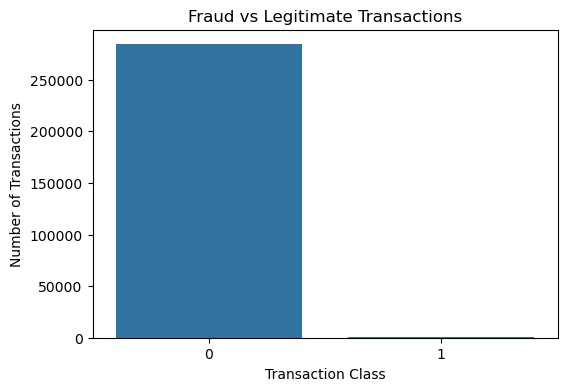

In [137]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

Step 8 — Analyze Transaction Amount

In [138]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


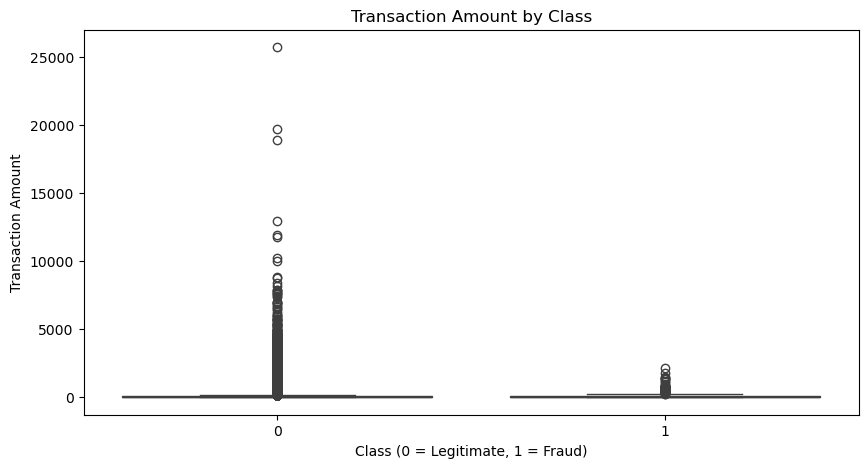

In [139]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Class",y="Amount",data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

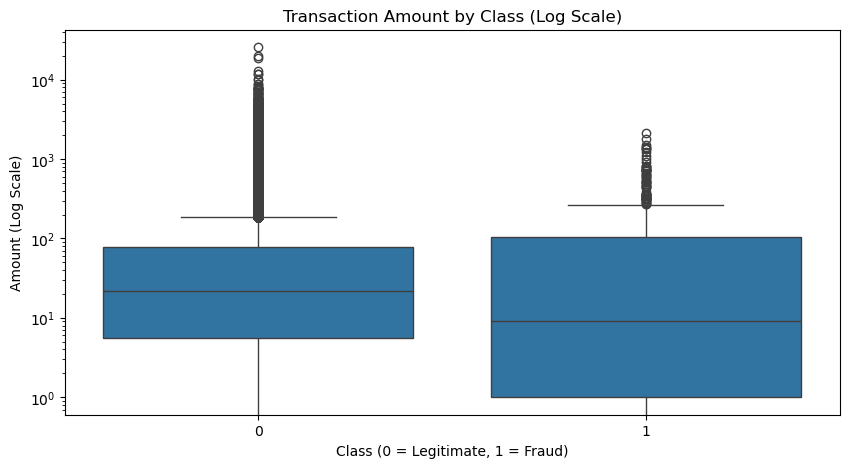

In [140]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Class",y="Amount",data=df)
plt.yscale("log")
plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount (Log Scale)")

plt.show()

In [141]:
print("Legitimate transactions:")
print(df[df["Class"] == 0]["Amount"].describe())

print("\nFraudulent transactions:")
print(df[df["Class"] == 1]["Amount"].describe())

Legitimate transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


Step 9 — Analyze Transaction Time

In [142]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

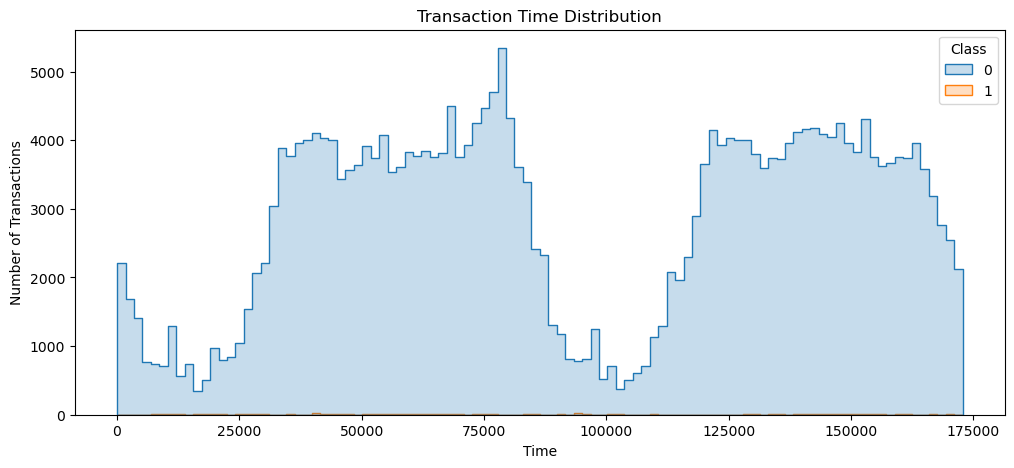

In [143]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df,x="Time",hue="Class",bins=100,element="step")
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

Step 10: Analyze Correlation

In [144]:
correlation = df.corr(numeric_only=True)["Class"].sort_values()

print(correlation)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


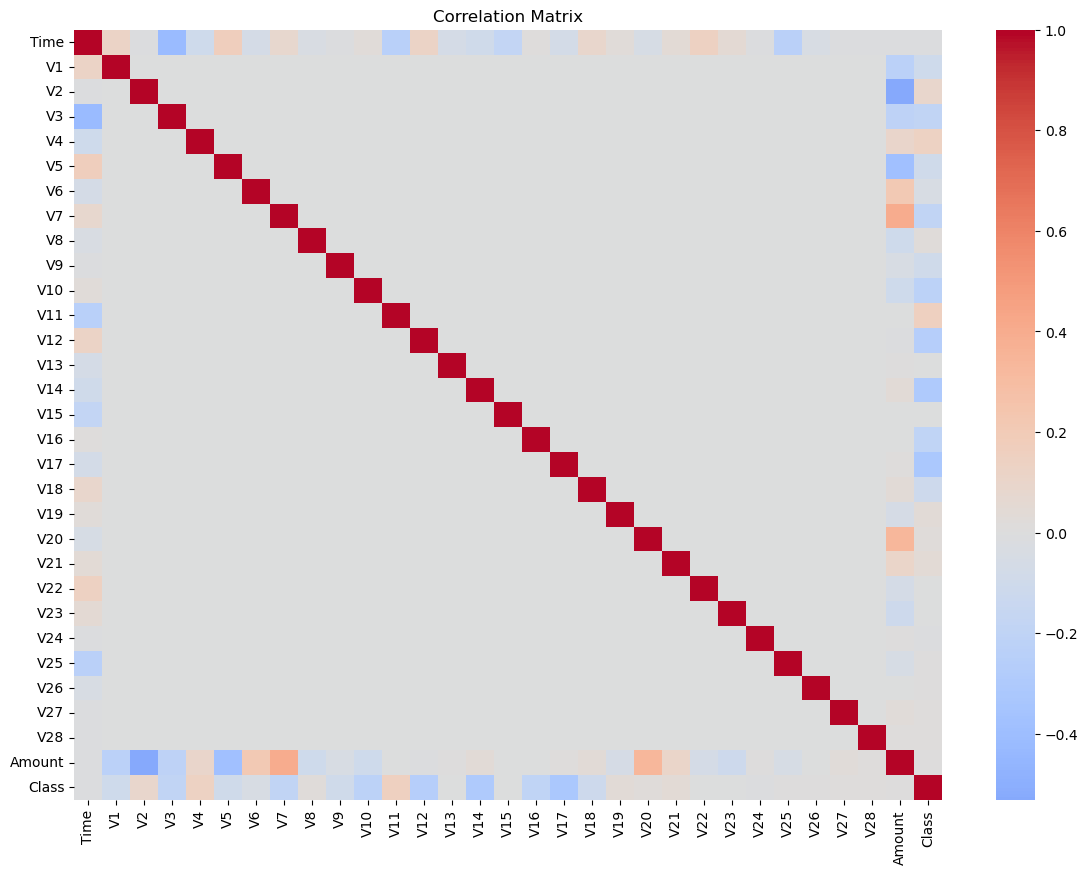

In [145]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

 Step 11: Analyze Important Features

The correlation analysis helps identify features that may contain useful information for fraud detection.

Because `V1`–`V28` are anonymized PCA-based features, we will not assign business meanings to them. Instead, we will visualize a few features to see how their distributions differ between legitimate and fraudulent transactions.

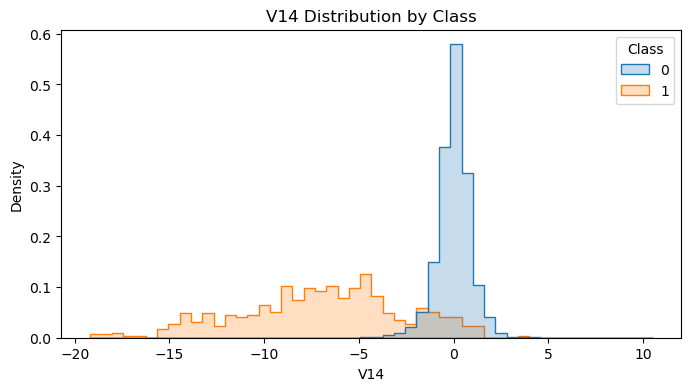

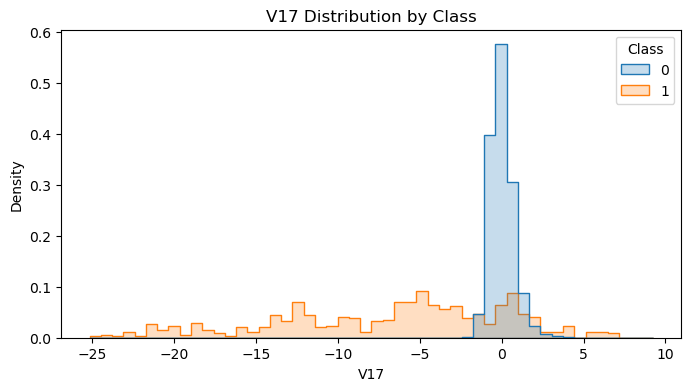

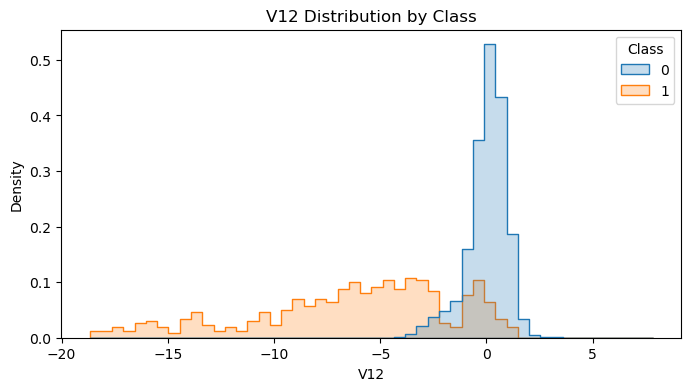

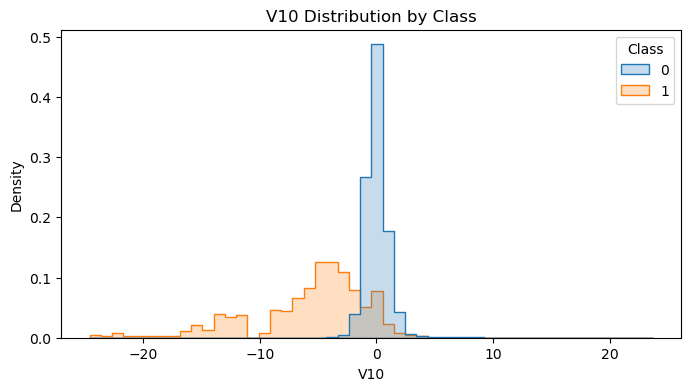

In [146]:
features = ["V14", "V17", "V12", "V10"]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df,x=feature,hue="Class",bins=50,element="step",stat="density",common_norm=False)
    plt.title(f"{feature} Distribution by Class")
    plt.show()

 Step 12: Prepare Data for Machine Learning

We will separate the target variable (`Class`) from the input features.

- `X` contains the transaction features.
- `y` contains the fraud label.
- We will use a stratified split so that the small number of fraudulent transactions is represented in each dataset.

In [147]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


Step 13: Create Training and Validation Sets

The validation set will be used to compare models and tune the fraud detection threshold.

The test set will remain untouched until the final evaluation.

In [148]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [149]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [150]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [151]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

 Step 14: Scale Features for Logistic Regression

Logistic Regression works better when numerical features are on similar scales.

We will:

- fit the scaler only on the training data
- transform the validation data using the same scaler
- transform the test data using the same scaler

This prevents information from the validation or test sets from leaking into training.

In [152]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [153]:
scaler.fit_transform(X_train)

array([[ 1.41158751,  0.99337908, -0.45603659, ...,  0.19191152,
        -0.09910576, -0.32249376],
       [ 0.62314085,  1.03850725, -0.02934912, ...,  0.00639701,
        -0.21152423, -0.33976388],
       [-1.13068022, -0.50676613,  0.36606499, ...,  0.09413695,
         0.56642647,  0.34669349],
       ...,
       [-1.25471074,  0.54569899,  0.04401572, ...,  0.07676455,
         0.07564817, -0.17053266],
       [-1.48398822,  0.65325241,  0.18256566, ..., -0.14759091,
        -0.0184768 , -0.34813969],
       [-1.39061787, -0.30573748,  0.47027277, ...,  0.93509494,
         0.63073809, -0.32380996]])

In [154]:
scaler.transform(X_test)

array([[ 1.3871815 , -0.34471083,  0.85416023, ...,  1.31850867,
         0.89058207, -0.25995439],
       [-1.58013819, -1.44498471, -1.67648235, ...,  0.27380388,
        -1.56632492, -0.30442595],
       [-0.13812017, -1.82615312,  1.40617205, ...,  1.36437772,
         1.55873319, -0.04828573],
       ...,
       [ 1.49899849, -0.53525491,  0.41575818, ...,  0.04301426,
         0.44344588, -0.28631824],
       [ 1.45096562,  1.10222743, -0.65718284, ..., -0.00616097,
        -0.17410048, -0.27211925],
       [-0.92286066,  0.62649961, -0.36552499, ...,  0.06140638,
         0.1529954 , -0.11277946]])

 Step 15: Train Logistic Regression

Logistic Regression is used as our baseline model.

Because the dataset is highly imbalanced, we use `class_weight="balanced"` so that fraudulent transactions receive more importance during training.

In [155]:
class_weight="balanced"

In [156]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

17 — Make predictions

In [157]:
y_pred = model.predict(X_test_scaled)

y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [158]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [159]:
y_proba

array([0.00569098, 0.06755242, 0.00011903, ..., 0.00026008, 0.00375493,
       0.08229136])

 Step 16: Evaluate Logistic Regression on Validation Data

Since fraud detection is highly imbalanced, we will focus on:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Accuracy alone is not sufficient for this problem.

In [160]:
from sklearn.metrics import *

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [161]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

ROC-AUC: 0.9720834996210077
PR-AUC: 0.7189705771419241


In [162]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55478  1386]
 [    8    90]]


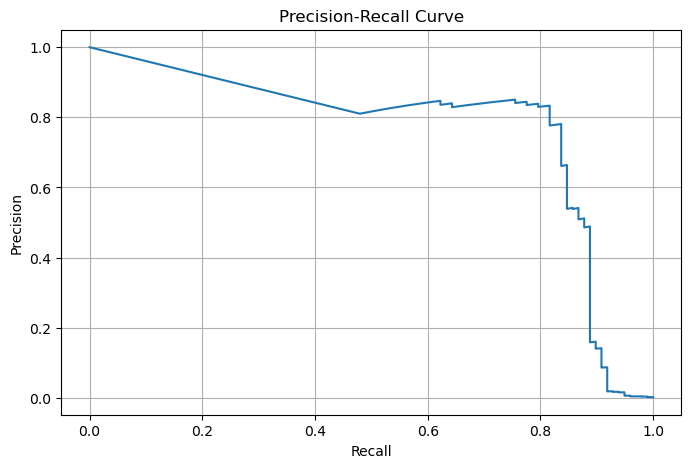

In [163]:
precision, recall, thresholds = precision_recall_curve(y_test,y_proba)
plt.figure(figsize=(8, 5))
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

 Step 17: Tune the Decision Threshold

A model outputs a probability that a transaction is fraudulent.

By default, we classify a transaction as fraud when:

`probability >= 0.50`

However, changing this threshold changes the balance between precision and recall.

We will test several thresholds on the validation set and select the threshold with the highest F1-score.

In [164]:
thresholds_to_test = np.arange(0.05, 1.00, 0.05)

results = []

for threshold in thresholds_to_test:
    predictions = (y_proba >= threshold).astype(int)
    precision_score_value = (((predictions == 1) & (y_test.values == 1)).sum()/ max((predictions == 1).sum(), 1))
    recall_score_value = (((predictions == 1) & (y_test.values == 1)).sum()/ max((y_test.values == 1).sum(), 1))
    f1 = f1_score(y_test, predictions)
    results.append([threshold,precision_score_value,recall_score_value,f1])

threshold_results = pd.DataFrame(results,columns=["Threshold", "Precision", "Recall", "F1"])
threshold_results

,Threshold,Precision,Recall,F1
0,0.05,0.004994,0.959184,0.009937
1,0.10,0.008152,0.948980,0.016165
2,0.15,0.011954,0.948980,0.023610
3,0.20,0.016408,0.938776,0.032252
4,0.25,0.021256,0.918367,0.041551
5,0.30,0.027347,0.918367,0.053113
6,0.35,0.034273,0.918367,0.066079
7,0.40,0.042155,0.918367,0.080609
8,0.45,0.050676,0.918367,0.096051
9,0.50,0.060976,0.918367,0.114358


In [165]:
threshold_results.sort_values("F1",ascending=False).head(10)

,Threshold,Precision,Recall,F1
18,0.95,0.390135,0.887755,0.542056
17,0.90,0.247159,0.887755,0.386667
16,0.85,0.184713,0.887755,0.305800
15,0.80,0.159633,0.887755,0.270607
14,0.75,0.140351,0.897959,0.242759
13,0.70,0.121253,0.908163,0.213942
12,0.65,0.101947,0.908163,0.183316
11,0.60,0.086745,0.908163,0.158363
10,0.55,0.072934,0.918367,0.135135
9,0.50,0.060976,0.918367,0.114358


In [166]:
test_proba = model.predict_proba(X_test_scaled)[:, 1]

In [167]:
best_threshold = 0.95

test_pred = (test_proba >= best_threshold).astype(int)

In [168]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.89      0.54        98

    accuracy                           1.00     56962
   macro avg       0.69      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [169]:
cm = confusion_matrix(y_test, test_pred)

print(cm)

[[56728   136]
 [   11    87]]


In [170]:
print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))

Precision: 0.3901345291479821
Recall: 0.8877551020408163
F1: 0.5420560747663551


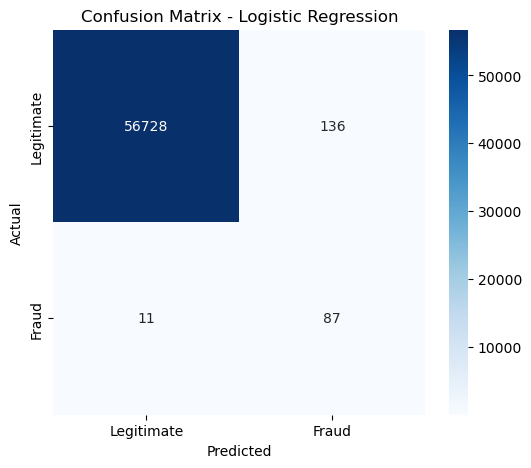

In [171]:
plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Legitimate", "Fraud"],yticklabels=["Legitimate", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

step 18: Train Random Forest

In [172]:
# Step 13: Create Training and Validation Sets

from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training shape:", X_train_new.shape)
print("Validation shape:", X_val.shape)

print("\nTraining class distribution:")
print(y_train_new.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training shape: (182276, 30)
Validation shape: (45569, 30)

Training class distribution:
Class
0    181961
1       315
Name: count, dtype: int64

Validation class distribution:
Class
0    45490
1       79
Name: count, dtype: int64


In [173]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,max_depth=12,class_weight="balanced",random_state=42,n_jobs=-1)
rf_model.fit(X_train_new, y_train_new)
print("Random Forest training completed.")

Random Forest training completed.


In [174]:
X_train_new

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
1458,1131.0,-0.441959,1.080868,1.410925,0.096693,0.135221,-0.706547,0.666114,0.013606,-0.507651,...,0.128156,-0.202324,-0.469792,0.065107,0.364271,-0.253785,0.079310,0.263524,0.100546,7.15
119883,75619.0,1.226589,0.169271,0.326460,0.493162,-0.123181,-0.313537,-0.009737,-0.048594,0.058451,...,-0.093960,-0.247942,-0.696903,0.113911,-0.289866,0.190943,0.145525,-0.014312,0.013489,9.99
177219,123088.0,1.708188,-0.698579,-0.964903,0.474704,-0.260791,0.238362,-0.589549,0.055753,1.165361,...,0.315986,0.031552,-0.082551,0.077579,-0.017251,-0.472592,0.362583,-0.016077,0.022792,171.52
191980,129483.0,2.096642,0.093645,-2.159035,0.955814,1.070886,-0.064135,0.432008,-0.123855,0.193407,...,-0.327625,-0.005335,0.152805,-0.165407,-1.468552,0.579626,-0.417287,-0.025580,-0.089699,1.00
252575,155871.0,-0.569459,-0.956243,2.007415,-1.590362,-0.186744,-0.842440,-0.697689,-0.005533,1.951300,...,0.318365,0.366197,1.234458,-0.000220,0.030027,-0.725066,-0.083545,0.068478,-0.007934,21.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24156,33092.0,0.016195,0.837004,1.412539,1.702548,-0.617590,0.261030,-0.535771,-1.523846,0.150172,...,-0.370322,1.545518,-0.160930,-0.005084,0.633019,0.803724,-0.087087,0.269657,0.239345,1.20
258612,158734.0,-3.385850,3.249002,-2.246492,0.993333,-0.729694,0.947889,-2.819625,-3.795863,-1.957584,...,1.263421,-2.225798,1.282028,-0.045040,0.039099,0.605973,1.199836,-0.763545,-0.077492,37.69
19453,30296.0,-1.737090,-0.890132,3.420714,0.395711,-0.067610,-0.335518,-0.215682,0.302557,1.503359,...,0.050463,-0.022212,-0.034168,-0.031295,0.659424,0.629384,-0.565606,-0.144327,-0.131447,79.50
129088,78945.0,-0.637908,1.143421,2.017952,-0.058035,0.144581,-0.646670,0.973703,-0.297624,-0.487969,...,0.199942,-0.171860,-0.209624,-0.008196,0.627083,-0.378823,0.019724,0.036641,-0.044300,3.96


In [175]:
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

In [176]:
rf_val_pred = (rf_val_proba >= 0.5).astype(int)

print(classification_report(y_val, rf_val_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.88      0.75      0.81        79

    accuracy                           1.00     45569
   macro avg       0.94      0.87      0.90     45569
weighted avg       1.00      1.00      1.00     45569



Step 19: Evaluate Random Forest on Validation Data

In [177]:
print("Random Forest ROC-AUC:",roc_auc_score(y_val, rf_val_proba))
print("Random Forest PR-AUC:",average_precision_score(y_val, rf_val_proba))

Random Forest ROC-AUC: 0.9507510344462964
Random Forest PR-AUC: 0.7806412267978495


In [178]:
rf_cm = confusion_matrix(y_val, rf_val_pred)
print(rf_cm)

[[45482     8]
 [   20    59]]


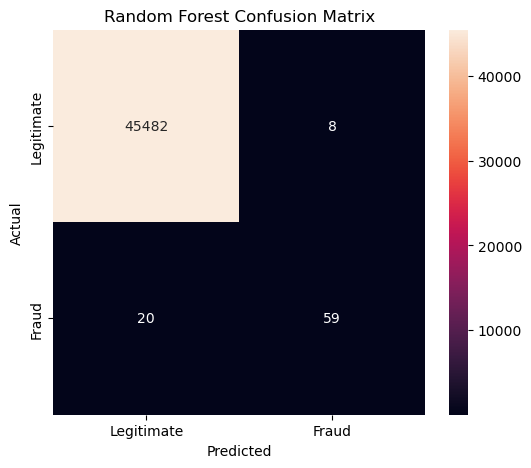

In [179]:
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm,annot=True,fmt="d",xticklabels=["Legitimate", "Fraud"],yticklabels=["Legitimate", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

27 — Feature importance

In [180]:
feature_importance = pd.DataFrame({"Feature": X_train_new.columns,"Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values("Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
14,V14,0.182433
4,V4,0.116375
10,V10,0.113124
12,V12,0.103556
17,V17,0.082872
3,V3,0.062285
16,V16,0.055835
11,V11,0.051965
2,V2,0.033477
7,V7,0.022456


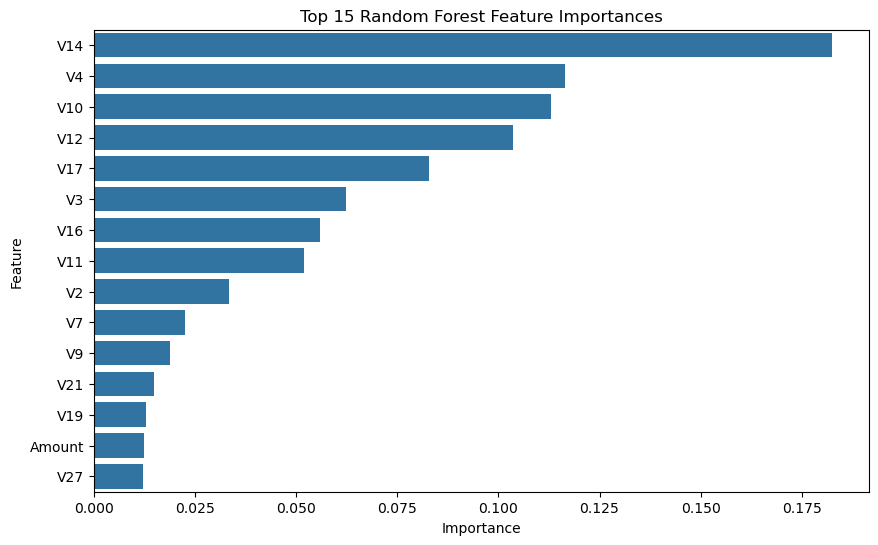

In [181]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

 Step 20: Tune the Random Forest Decision Threshold

In [182]:
rf_val_pred = (rf_val_proba >= 0.5).astype(int)

In [183]:
thresholds = np.arange(0.05, 1.00, 0.05)

rf_threshold_results = []

for threshold in thresholds:
    predictions = (rf_val_proba >= threshold).astype(int)
    
    precision = precision_score(y_val, predictions, zero_division=0)
    recall = recall_score(y_val, predictions, zero_division=0)
    f1 = f1_score(y_val, predictions, zero_division=0)
    
    rf_threshold_results.append({"Threshold": threshold,"Precision": precision,"Recall": recall,"F1": f1})

rf_threshold_results = pd.DataFrame(rf_threshold_results)
rf_threshold_results

,Threshold,Precision,Recall,F1
0,0.05,0.150442,0.860759,0.256121
1,0.10,0.368715,0.835443,0.511628
2,0.15,0.637255,0.822785,0.718232
3,0.20,0.732558,0.797468,0.763636
4,0.25,0.794872,0.784810,0.789809
5,0.30,0.826667,0.784810,0.805195
6,0.35,0.861111,0.784810,0.821192
7,0.40,0.873239,0.784810,0.826667
8,0.45,0.882353,0.759494,0.816327
9,0.50,0.880597,0.746835,0.808219


In [184]:
best_rf_row = rf_threshold_results.loc[
    rf_threshold_results["F1"].idxmax()
]

best_rf_row

Threshold    0.400000
Precision    0.873239
Recall       0.784810
F1           0.826667
Name: 7, dtype: float64

In [185]:
best_rf_threshold = best_rf_row["Threshold"]

print("Best threshold:", best_rf_threshold)
print("Precision:", best_rf_row["Precision"])
print("Recall:", best_rf_row["Recall"])
print("F1:", best_rf_row["F1"])

Best threshold: 0.4
Precision: 0.8732394366197183
Recall: 0.7848101265822784
F1: 0.8266666666666667


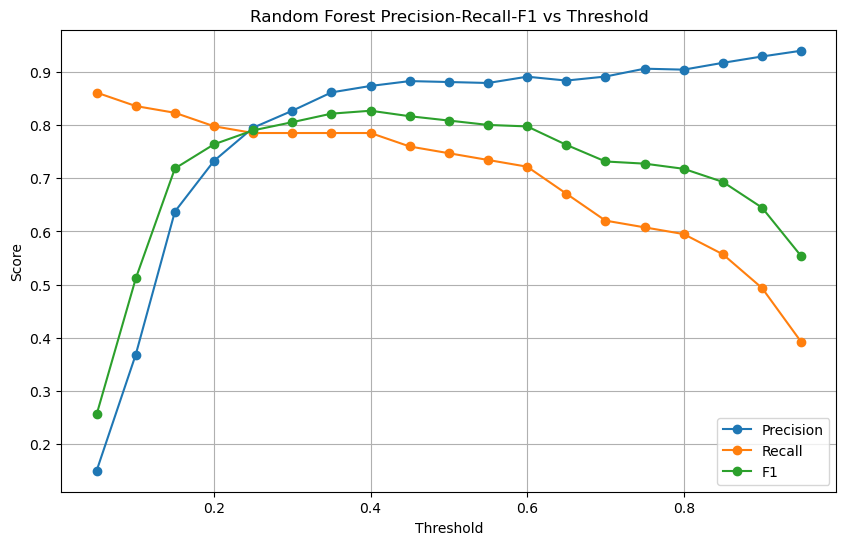

In [186]:
plt.figure(figsize=(10, 6))
plt.plot(rf_threshold_results["Threshold"],rf_threshold_results["Precision"],marker="o",label="Precision")
plt.plot(rf_threshold_results["Threshold"],rf_threshold_results["Recall"],marker="o",label="Recall")
plt.plot(rf_threshold_results["Threshold"],rf_threshold_results["F1"],marker="o",label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest Precision-Recall-F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [187]:
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

In [188]:
final_threshold = 0.40
rf_test_pred = (rf_test_proba >= final_threshold).astype(int)

In [189]:
print(classification_report(y_test,rf_test_pred,target_names=["Legitimate", "Fraud"]))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [190]:
final_cm = confusion_matrix(y_test, rf_test_pred)
print(final_cm)

[[56847    17]
 [   17    81]]


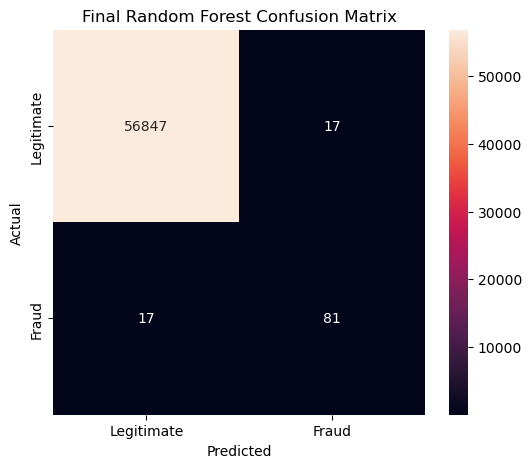

In [191]:
plt.figure(figsize=(6, 5))
sns.heatmap(final_cm,annot=True,fmt="d",xticklabels=["Legitimate", "Fraud"],yticklabels=["Legitimate", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest Confusion Matrix")
plt.show()

Step 21: Final Evaluation on the Untouched Test Set

In [193]:
from sklearn.metrics import classification_report, confusion_matrix
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
final_threshold = best_rf_threshold
rf_test_pred = (rf_test_proba >= final_threshold).astype(int)
print("Final Random Forest Evaluation:")
print(classification_report(y_test, rf_test_pred))

Final Random Forest Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [194]:
# Confusion Matrix

cm = confusion_matrix(y_test, rf_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56847    17]
 [   17    81]]


# Project Conclusion

The Random Forest model was trained to detect fraudulent credit card transactions
using the ULB Credit Card Fraud Detection dataset.

The project addressed the severe class imbalance in the dataset using class-weighted
Random Forest training and evaluated the model using precision, recall, F1-score,
and a tuned decision threshold.

On the untouched test set, the final model achieved approximately 83% precision,
83% recall, and 83% F1-score for the fraud class.

The results show that the model can identify a substantial portion of fraudulent
transactions while limiting false positives.